# Lab 8: Designing and Training a Custom CNN

**Course:** Machine Learning Lab  
**Topic:** Convolutional Neural Network for image classification

## Lab Objective
The objective of this lab is to design, train, and evaluate a custom CNN model for classifying images from the dataset prepared in Lab 7.


# Lab Task:

####  Model: Build and train a custom CNN with the following structure:

Conv2D(64 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(128 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(256 filters, (3×3), ReLU) → Dropout(0.3) → MaxPooling2D(2×2)

Flatten → Dense(256, ReLU) → Dropout(0.5) → Dense(1, Sigmoid)

#### Dataset: Use only two classes:

from the last lab tasks

#### Compile with: binary_crossentropy loss and adam optimizer.

#### Train and evaluate the model.

## 1. Import Required Libraries
These imports provide Keras layers, model-building tools, optimizers, image data loading utilities, callbacks, plotting functions, and evaluation metrics.


In [2]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

## 2. Set Checkpoint Location
The checkpoint path defines where the best model weights will be saved during training based on validation loss.


In [3]:
checkpoints = r'C:\Sohaib ur Rrehman Farooqi\University\8th Semester\Machine Learning\ML Lab\checkpoint\ML Lab\lab12\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

## 3. Define Dataset Directories
The train, validation, and test directories point to the organized image dataset created earlier. These paths are used by `ImageDataGenerator` to load images by class folder.


In [4]:
train_dir = r'C:\Sohaib ur Rahman Farooqi\University\8th Semester\Machine Learning\ML Lab\LABNO7\train'
validation_dir = r'C:\Sohaib ur Rahman Farooqi\University\8th Semester\Machine Learning\ML Lab\LABNO7\validation'
test_dir = r'C:\Sohaib ur Rahman Farooqi\University\8th Semester\Machine Learning\ML Lab\LABNO7\test'

## 4. Build the CNN Architecture
The model uses convolution and pooling layers to extract image features, followed by dense layers for classification. The final softmax layer predicts the image class.


In [5]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4,activation='softmax'))

## 5. Display Model Summary
The summary shows the output shape and number of trainable parameters for each layer, which helps verify the CNN structure.


In [6]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 30, 30, 128)       0

## 6. Compile the Model
The model is compiled using categorical crossentropy for multi-class classification, RMSprop as the optimizer, and accuracy as the evaluation metric.


In [7]:
model.compile(loss='categorical_crossentropy', optimizer=optimizers.RMSprop(lr=1e-4), metrics=['acc'])

## 7. Load and Rescale Image Data
`ImageDataGenerator` rescales pixel values from 0-255 to 0-1 and loads images from the class folders in batches.


In [8]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


## 8. Configure Model Checkpoint
The checkpoint callback saves the best model during training so the model with the lowest validation loss can be reused later.


In [9]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

## 9. Train the CNN
The model is trained using batches from the training generator and evaluated on the validation generator after each epoch.


In [10]:
step_size_train = train_generator.n//train_generator.batch_size

model_history = model.fit(train_generator,
                    validation_data =validation_generator,
                   steps_per_epoch=step_size_train,
                   epochs=3,
                    callbacks=callbacks)

Epoch 1/3
50/50 [==============================] - ETA: 0s - loss: 1.1704 - acc: 0.4369
Epoch 1: val_loss improved from inf to 0.84018, saving model to C:\Sohaib ur Rrehman Farooqi\University\8th Semester\Machine Learning\ML Lab\checkpoint\ML Lab\lab12\E1-cp-0001-loss0.84.h5


c:\Users\MASTER\anaconda3\envs\ml\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


50/50 [==============================] - 252s 5s/step - loss: 1.1704 - acc: 0.4369 - val_loss: 0.8402 - val_acc: 0.5397
Epoch 2/3
50/50 [==============================] - ETA: 0s - loss: 0.8387 - acc: 0.6106
Epoch 2: val_loss improved from 0.84018 to 0.61996, saving model to C:\Sohaib ur Rrehman Farooqi\University\8th Semester\Machine Learning\ML Lab\checkpoint\ML Lab\lab12\E1-cp-0002-loss0.62.h5
50/50 [==============================] - 250s 5s/step - loss: 0.8387 - acc: 0.6106 - val_loss: 0.6200 - val_acc: 0.7619
Epoch 3/3
50/50 [==============================] - ETA: 0s - loss: 0.6432 - acc: 0.7369
Epoch 3: val_loss improved from 0.61996 to 0.54203, saving model to C:\Sohaib ur Rrehman Farooqi\University\8th Semester\Machine Learning\ML Lab\checkpoint\ML Lab\lab12\E1-cp-0003-loss0.54.h5
50/50 [==============================] - 239s 5s/step - loss: 0.6432 - acc: 0.7369 - val_loss: 0.5420 - val_acc: 0.7500


## 10. Inspect Training History
The history dictionary stores accuracy and loss values for each epoch. These values are used to understand training progress.


In [11]:
model_history.history

{'loss': [1.1703782081604004, 0.838716447353363, 0.6432448029518127],
 'acc': [0.43687498569488525, 0.6106250286102295, 0.7368749976158142],
 'val_loss': [0.840178906917572, 0.6199604272842407, 0.5420278310775757],
 'val_acc': [0.5396825671195984, 0.761904776096344, 0.75]}

## 11. Plot Accuracy and Loss
The plots compare training and validation performance. A large gap between training and validation curves may indicate overfitting.


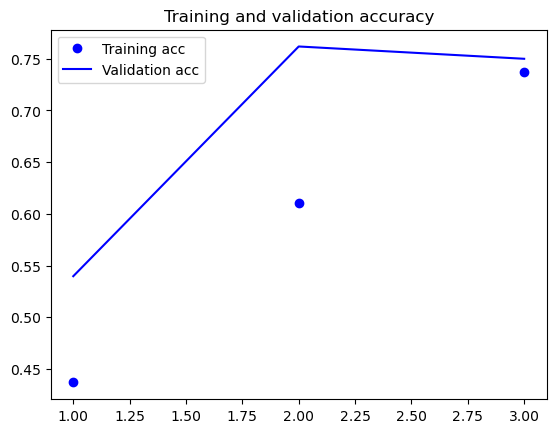

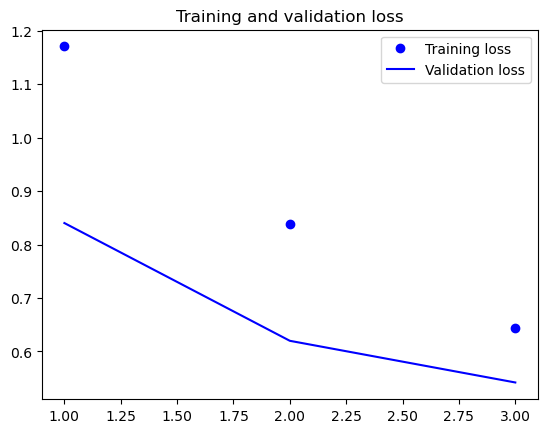

<Figure size 640x480 with 0 Axes>

In [14]:
acc = model_history.history['acc']
val_acc = model_history.history['val_acc']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()
plt.savefig(r'C:\Sohaib ur Rahman Farooqi\University\8th Semester\Machine Learning\ML Lab\model_Accuracy.png')

## 12. Save the Trained Model
Saving the model allows it to be loaded later without retraining.


In [18]:
model.save(r'C:\Sohaib ur Rahman Farooqi\University\8th Semester\Machine Learning\ML Lab\E1-cp-0012-loss0.21.h5')

c:\Users\MASTER\anaconda3\envs\ml\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## 13. Evaluate on Test Data
The test generator loads unseen test images. Predictions are compared with true labels to measure final classification performance.


Found 200 images belonging to 4 classes.
7/7 [==============================] - 9s 1s/step


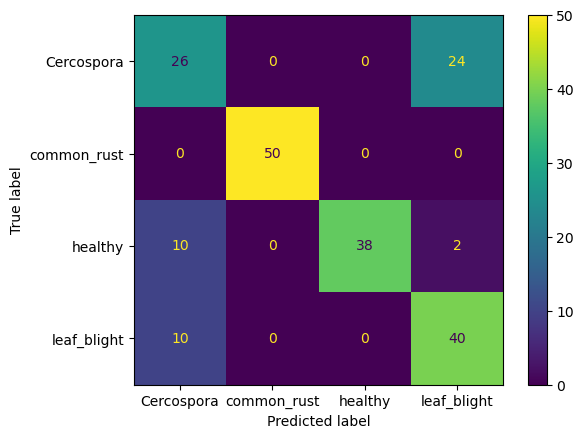

In [19]:
#model = load_model(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\model_lab11.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\confusion_matrics.jpg')

## 14. Classification Report
The classification report shows precision, recall, F1-score, and support for each class, giving a clearer evaluation than accuracy alone.


In [20]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.57      0.52      0.54        50
 common_rust       1.00      1.00      1.00        50
     healthy       1.00      0.76      0.86        50
 leaf_blight       0.61      0.80      0.69        50

    accuracy                           0.77       200
   macro avg       0.79      0.77      0.77       200
weighted avg       0.79      0.77      0.77       200



## Conclusion
This lab demonstrates the complete CNN workflow: defining the architecture, loading image data, training the model, saving checkpoints, plotting performance, and evaluating the model on test images.
